In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", palette="muted", font_scale=1.1)
plt.rcParams.update({"axes.grid": False, "figure.dpi": 120})

MODEL_PATH = "../models_dict_latest/ensemble_model.joblib"
TRAIN_CSV  = "../data/Copy of Float Sample Data - Sheet5.csv"

saved = joblib.load(MODEL_PATH)
model = saved["model"]            # EnsembleClassifier
clf = model.classifier          # CatBoostClassifier
label_names = saved["label_names"]
tf_encoder  = saved["tf_encoder"]

print(f"Classifier : {type(clf).__name__}")
print(f"Trees      : {clf.tree_count_}")
print(f"Classes    : {len(label_names)}")
print(f"Features   : {clf.get_feature_importance().shape[0]}")
print(f"Labels     : {label_names}")

Classifier : CatBoostClassifier
Trees      : 500
Classes    : 11
Features   : 50
Labels     : ['1320 prepaid expense', '1358 bloom app inc', '1359 1478897', '1820 office furniture equipment', '5410 wage salary', '5626 training development', '5700 office expense', '5773 software license', '5784 travel entertainment', '5785 meal entertainment', 'account payable sage']


In [2]:
# ── Reconstruct feature names (same order used during training) ──────────────
from float_categorization.pre_processing.pre_processor import PreProcessor
from float_categorization.runners.decide_deterministic import deterministic_decider
from float_categorization.constant import LABEL_COL
import spacy

df_raw = pd.read_csv(TRAIN_CSV)
matched, unmatched = deterministic_decider(df_raw, use_deterministic=True)

# Remove deterministic-label rows (same logic as training pipeline)
if not matched.empty:
    det_labels = set(matched["predicted_label"].unique())
    label_col = LABEL_COL.strip().casefold()
    nlp = spacy.load("en_core_web_sm")
    nlp.disable_pipes("ner", "parser")
    raw_to_cleaned = {}
    for lbl in unmatched[label_col].dropna().unique():
        doc = nlp(lbl)
        raw_to_cleaned[lbl] = " ".join(
            t.lemma_ for t in doc if not t.is_stop and not t.is_punct and t.text.strip()
        )
    remove_labels = {r for r, c in raw_to_cleaned.items() if c in det_labels}
    unmatched = unmatched[~unmatched[label_col].isin(remove_labels)]

processor = PreProcessor(unmatched, is_training=True)
processor()
X, y = processor.process_for_training()

tfidf_names = list(processor.tf_encoder.vectorizer.get_feature_names_out())
manual_names = list(processor.X_initial.columns)
FEATURE_NAMES = manual_names + tfidf_names

print(f"Manual features ({len(manual_names)}): {manual_names}")
print(f"TF-IDF features ({len(tfidf_names)}): {tfidf_names}")
print(f"Total: {len(FEATURE_NAMES)}")

Loading spacy text processing model...
Spacy model loaded successfully
Manual features (23): ['spender', 'approver', 'payment authorizer', 'amount_parsed', 'month', 'day_of_week', 'payee_encoded', 'payee_k_travel', 'payee_k_food', 'payee_k_software', 'payee_k_amazon', 'account_is_null', 'initial amount_is_null', 'initial currency_is_null', 'last 4 digits_is_null', 'invoice number_is_null', 'fx initial currency_is_null', 'fx initial amount_is_null', 'conversion rate_is_null', 'detail_is_null', 'transaction type_bill payment', 'transaction type_purchase', 'transaction type_refund']
TF-IDF features (27): ['auto', 'card', 'cypress', 'cypress hill', 'cypress hill use', 'cypress portfolio', 'cypress portfolio 20', 'financial', 'limit', 'manage', 'match renewal', 'match renewal requirement', 'need', 'passtime', 'platform', 'product', 'product manage', 'product manage cypress', 'purchase', 'renewal', 'spring', 'update', 'update card', 'update card limit', 'use', 'use passtime', 'use passtime p

## 1. Model Parameters

The hyper-parameters of the trained CatBoost model (tuned via Optuna).

In [3]:
params = clf.get_all_params()
show_keys = [
    "iterations", "depth", "learning_rate", "l2_leaf_reg", "random_strength",
    "loss_function", "border_count", "bagging_temperature", "grow_policy",
    "min_data_in_leaf", "leaf_estimation_method", "leaf_estimation_iterations",
    "bootstrap_type", "score_function",
]
params_df = pd.DataFrame(
    [(k, params.get(k, "—")) for k in show_keys],
    columns=["Parameter", "Value"],
)
display(params_df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Parameter,Value
iterations,500
depth,5
learning_rate,0.193124
l2_leaf_reg,1.722617
random_strength,3.547185
loss_function,MultiClass
border_count,254
bagging_temperature,1
grow_policy,SymmetricTree
min_data_in_leaf,1


## 2. Feature Importance — PredictionValuesChange (default)

CatBoost's default importance: the average change in the predicted value when the feature is used in a split. Higher = the feature shifts predictions more.

feature,importance,type
spender,15.68,manual
amount_parsed,14.23,manual
payee_encoded,12.10,manual
conversion rate_is_null,11.61,manual
month,9.21,manual
day_of_week,5.71,manual
payee_k_travel,5.31,manual
payee_k_software,4.47,manual
payment authorizer,4.04,manual
payee_k_food,3.10,manual


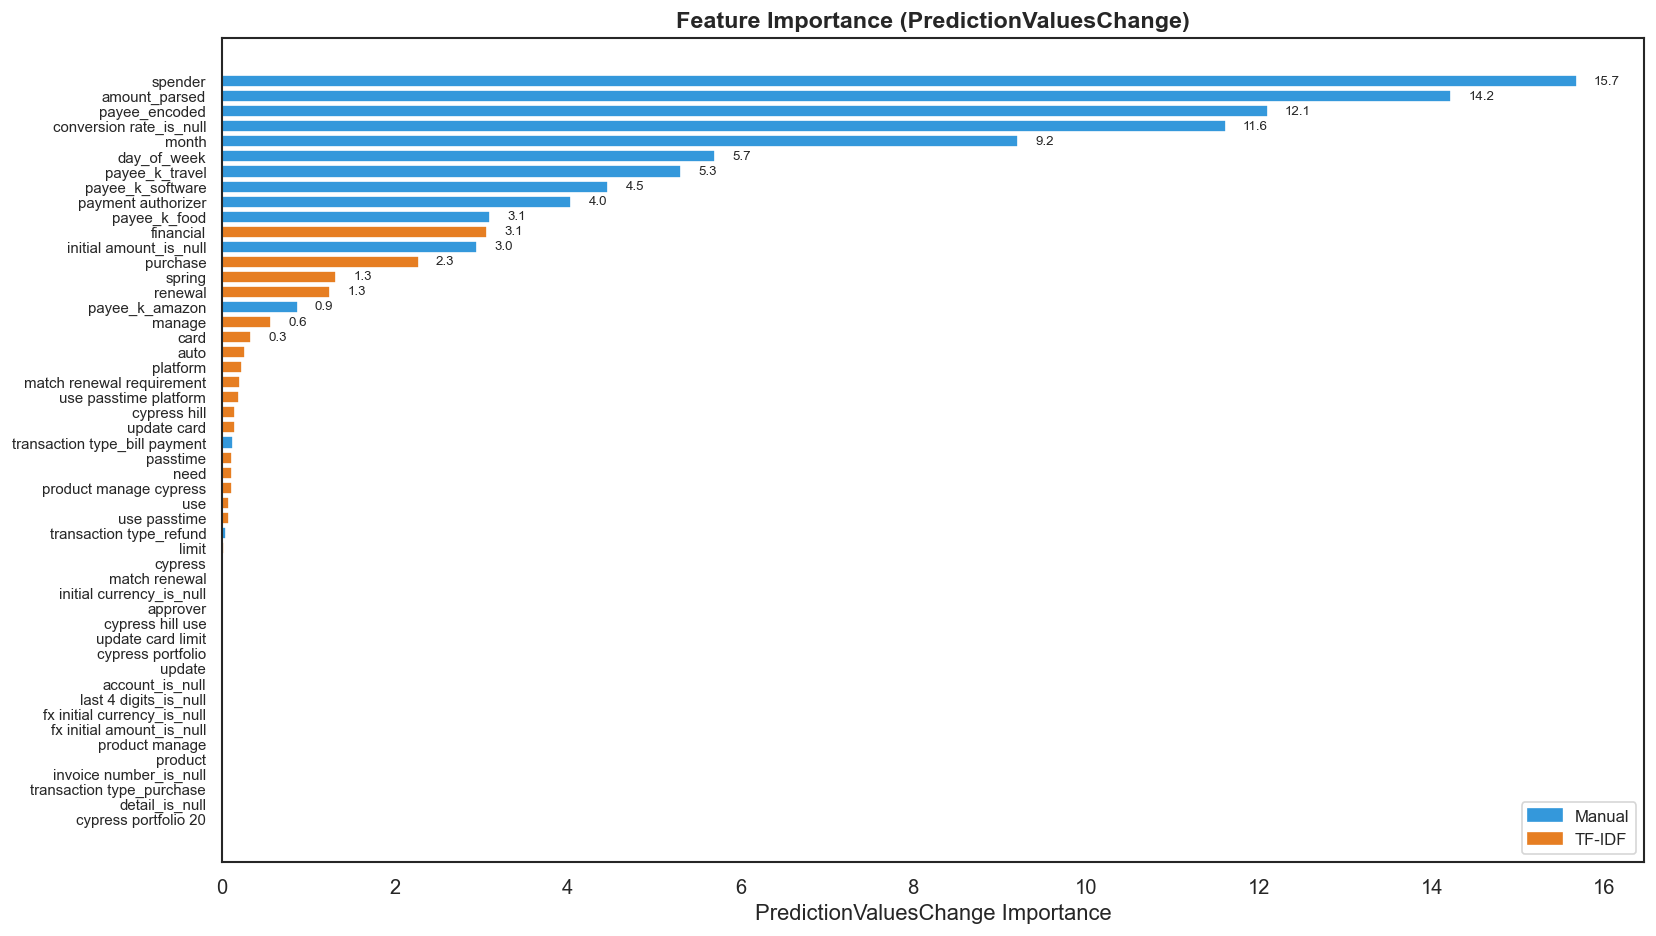

In [4]:
# Default importance (PredictionValuesChange)
imp_pvc = clf.get_feature_importance(type="PredictionValuesChange")
imp_df = pd.DataFrame({"feature": FEATURE_NAMES, "importance": imp_pvc})
imp_df["type"] = ["manual"] * len(manual_names) + ["tfidf"] * len(tfidf_names)
imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

# Table
display(imp_df.style.hide(axis="index").background_gradient(
    subset=["importance"], cmap="YlOrRd"
).format({"importance": "{:.2f}"}))

# Bar chart
fig, ax = plt.subplots(figsize=(14, 8))
colors = imp_df["type"].map({"manual": "#3498db", "tfidf": "#e67e22"}).values
ax.barh(imp_df["feature"], imp_df["importance"], color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("PredictionValuesChange Importance")
ax.set_title("Feature Importance (PredictionValuesChange)", fontsize=14, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#3498db", label="Manual"),
                   Patch(color="#e67e22", label="TF-IDF")],
          loc="lower right", fontsize=10)
for i, (_, row) in enumerate(imp_df.iterrows()):
    if row["importance"] > 0.3:
        ax.text(row["importance"] + 0.2, i, f"{row['importance']:.1f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Feature Importance — LossFunctionChange

How much the loss function changes when a feature is permuted (removed). More directly measures predictive value.

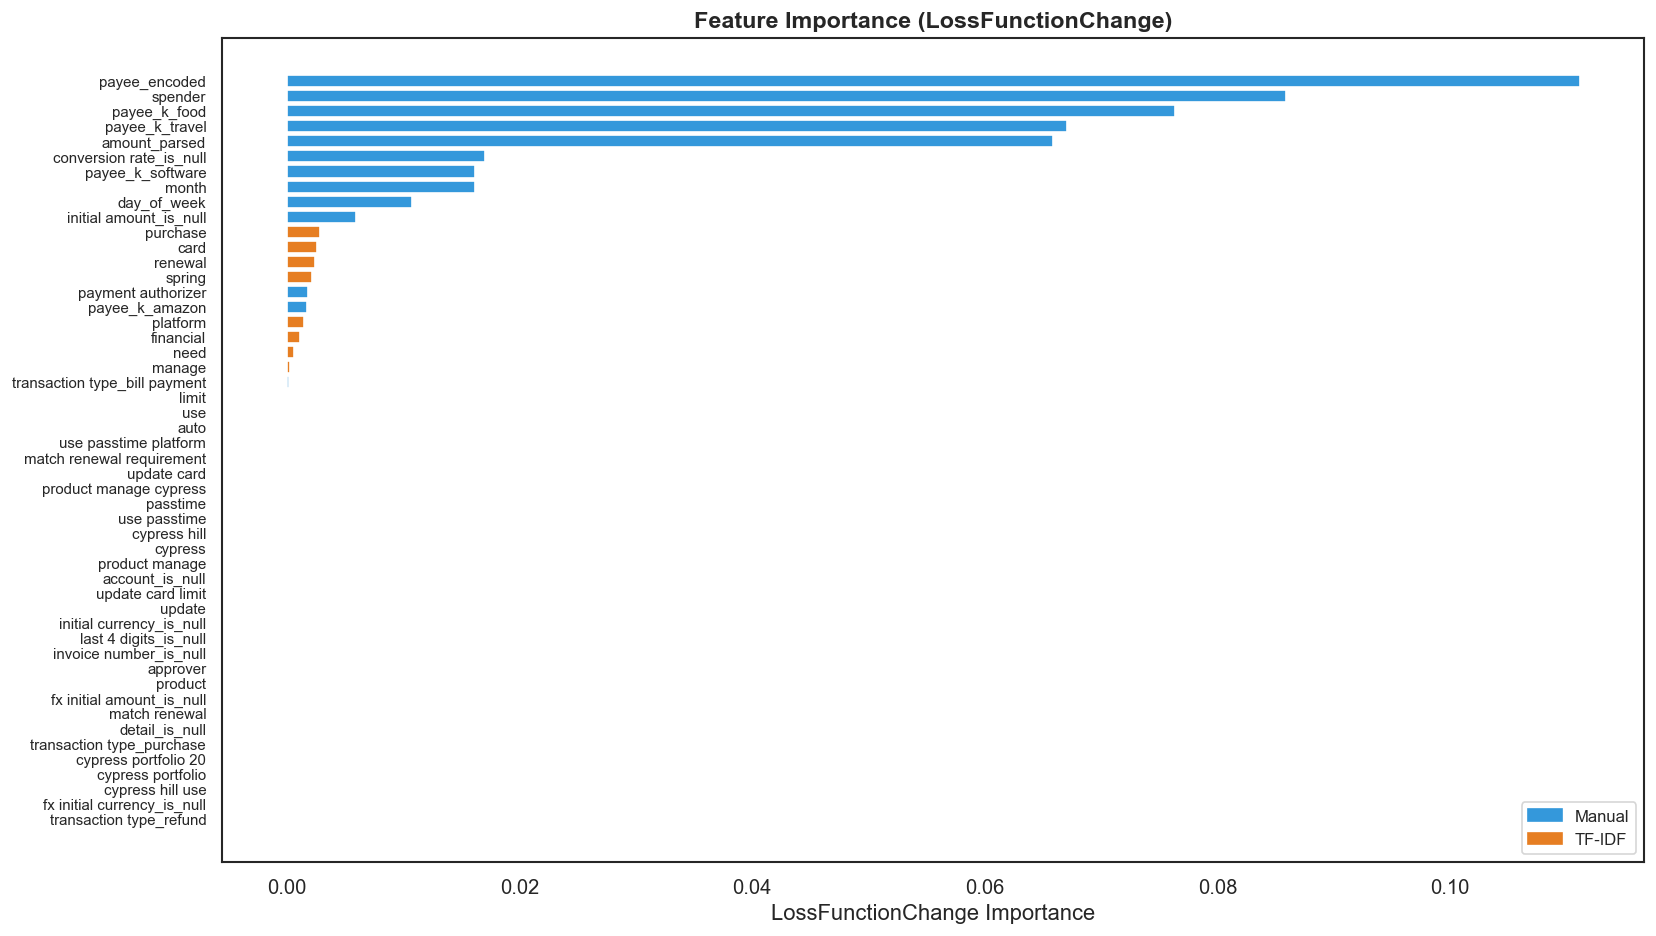

feature,importance,type
payee_encoded,0.1112,manual
spender,0.0859,manual
payee_k_food,0.0764,manual
payee_k_travel,0.0671,manual
amount_parsed,0.0659,manual
conversion rate_is_null,0.0170,manual
payee_k_software,0.0162,manual
month,0.0162,manual
day_of_week,0.0107,manual
initial amount_is_null,0.0059,manual


In [5]:
from catboost import Pool

pool = Pool(X, label=y.values.argmax(axis=1))
imp_lfc = clf.get_feature_importance(type="LossFunctionChange", data=pool)

lfc_df = pd.DataFrame({"feature": FEATURE_NAMES, "importance": imp_lfc})
lfc_df["type"] = ["manual"] * len(manual_names) + ["tfidf"] * len(tfidf_names)
lfc_df = lfc_df.sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8))
colors = lfc_df["type"].map({"manual": "#3498db", "tfidf": "#e67e22"}).values
ax.barh(lfc_df["feature"], lfc_df["importance"], color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("LossFunctionChange Importance")
ax.set_title("Feature Importance (LossFunctionChange)", fontsize=14, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
ax.legend(handles=[Patch(color="#3498db", label="Manual"),
                   Patch(color="#e67e22", label="TF-IDF")],
          loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

display(lfc_df.style.hide(axis="index").background_gradient(
    subset=["importance"], cmap="YlOrRd"
).format({"importance": "{:.4f}"}))

## 4. SHAP Values (per-class feature attribution)

SHAP values explain *how much each feature pushes the prediction toward or away from each class*. This gives per-class feature importance rather than a single global number.

In [7]:
# SHAP values: shape (n_samples, n_classes, n_features + 1)  — last column is bias
shap_raw = clf.get_feature_importance(type="ShapValues", data=pool)
n_classes = len(label_names)
n_features = len(FEATURE_NAMES)

print(f"SHAP raw shape: {shap_raw.shape}  →  (samples, classes, features+1)")

# Average |SHAP| per feature per class
shap_abs = np.abs(shap_raw[:, :, :n_features])        # drop bias column
shap_mean = shap_abs.mean(axis=0)                       # (n_classes, n_features)

shap_df = pd.DataFrame(shap_mean.T, index=FEATURE_NAMES, columns=label_names)

# Global SHAP importance = mean |SHAP| across all classes
shap_df["GLOBAL"] = shap_df.mean(axis=1)
shap_df = shap_df.sort_values("GLOBAL", ascending=False)

print(f"Mean |SHAP| per feature per class stored in shap_df ({shap_df.shape})")

SHAP raw shape: (3078, 11, 51)  →  (samples, classes, features+1)
Mean |SHAP| per feature per class stored in shap_df ((50, 12))


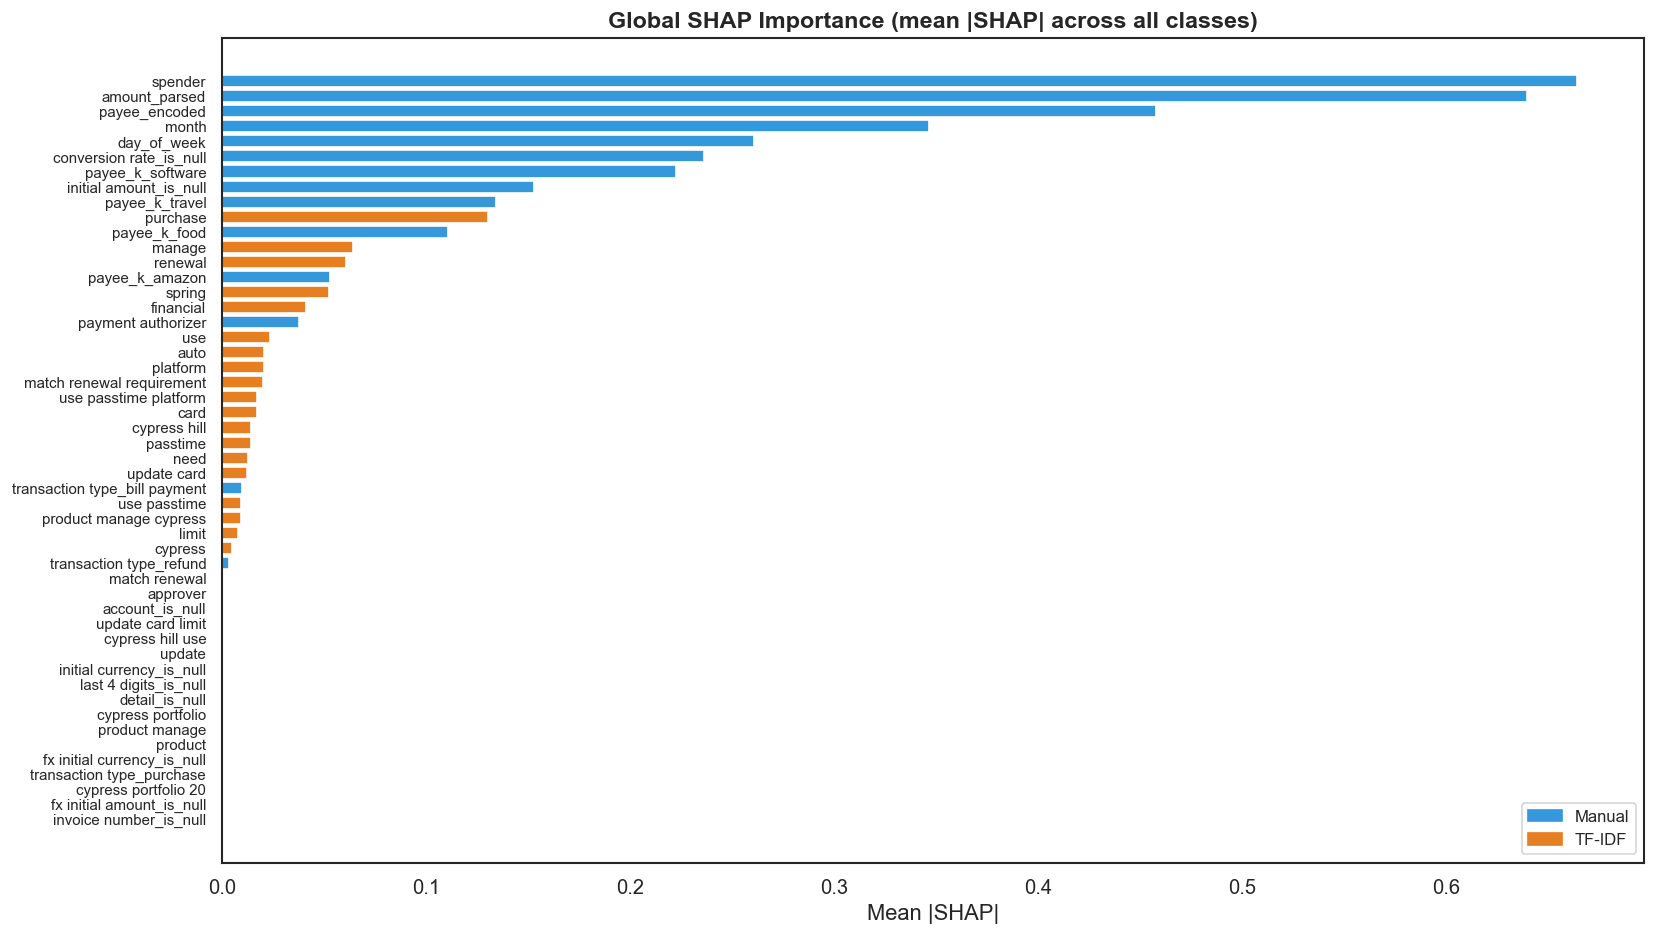

In [8]:
# ── Global SHAP importance bar ──
fig, ax = plt.subplots(figsize=(14, 8))
feat_type = ["manual" if f in manual_names else "tfidf" for f in shap_df.index]
colors = ["#3498db" if t == "manual" else "#e67e22" for t in feat_type]
ax.barh(shap_df.index, shap_df["GLOBAL"], color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP|")
ax.set_title("Global SHAP Importance (mean |SHAP| across all classes)", fontsize=14, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
ax.legend(handles=[Patch(color="#3498db", label="Manual"),
                   Patch(color="#e67e22", label="TF-IDF")],
          loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

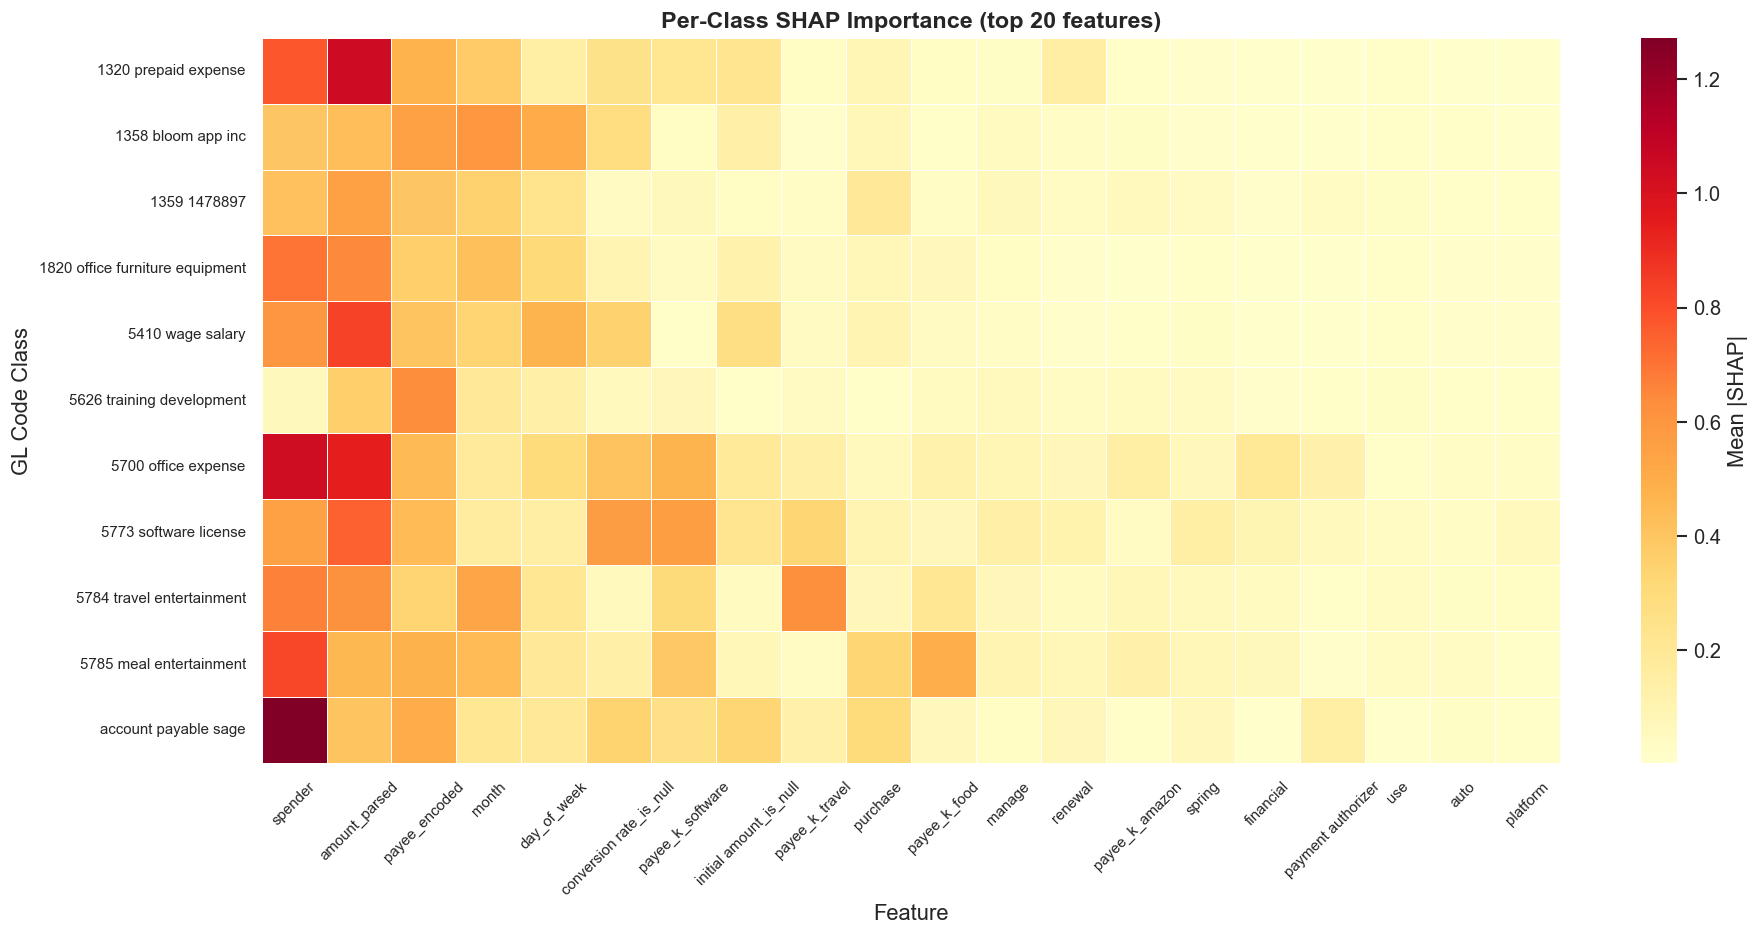

In [9]:
# ── Per-class SHAP heatmap (top 20 features) ──
top_feats = shap_df.drop(columns="GLOBAL").head(20)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    top_feats.T, cmap="YlOrRd", linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Mean |SHAP|"}, ax=ax,
)
ax.set_title("Per-Class SHAP Importance (top 20 features)", fontsize=14, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("GL Code Class")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

## 5. Top-3 Most Important Features per GL Code Class

Which features matter *most* for each specific class (by mean |SHAP|).

In [10]:
class_shap = shap_df.drop(columns="GLOBAL")
rows = []
for cls in label_names:
    top3 = class_shap[cls].sort_values(ascending=False).head(3)
    for rank, (feat, val) in enumerate(top3.items(), 1):
        rows.append({"GL Code": cls, "Rank": rank, "Feature": feat, "Mean |SHAP|": val})

top3_df = pd.DataFrame(rows)
pivot = top3_df.pivot(index="GL Code", columns="Rank", values="Feature")
pivot.columns = [f"#{c}" for c in pivot.columns]
vals_pivot = top3_df.pivot(index="GL Code", columns="Rank", values="Mean |SHAP|")
vals_pivot.columns = [f"#{c} |SHAP|" for c in vals_pivot.columns]

out = pd.concat([pivot, vals_pivot], axis=1)[["#1", "#1 |SHAP|", "#2", "#2 |SHAP|", "#3", "#3 |SHAP|"]]
display(out.style.format({c: "{:.4f}" for c in out.columns if "SHAP" in c})
        .background_gradient(subset=[c for c in out.columns if "SHAP" in c], cmap="YlOrRd"))

,#1,#1 |SHAP|,#2,#2 |SHAP|,#3,#3 |SHAP|
GL Code,,,,,,
1320 prepaid expense,amount_parsed,1.0479,spender,0.7742,payee_encoded,0.4779
1358 bloom app inc,month,0.5925,payee_encoded,0.5509,day_of_week,0.5076
1359 1478897,amount_parsed,0.5531,spender,0.4181,payee_encoded,0.3964
1820 office furniture equipment,spender,0.6999,amount_parsed,0.6441,month,0.4237
5410 wage salary,amount_parsed,0.8337,spender,0.6014,day_of_week,0.4714
5626 training development,payee_encoded,0.6348,amount_parsed,0.3550,month,0.1959
5700 office expense,spender,1.0441,amount_parsed,0.9443,payee_k_software,0.4720
5773 software license,amount_parsed,0.7475,conversion rate_is_null,0.5704,payee_k_software,0.5678
5784 travel entertainment,spender,0.6623,payee_k_travel,0.6268,amount_parsed,0.6145


## 6. Feature Interaction Strength

CatBoost can report the strongest pairwise *interaction* effects — pairs of features that together contribute more than each alone.

In [11]:
# Interaction strengths: array of (feature_idx_1, feature_idx_2, strength)
interactions = clf.get_feature_importance(type="Interaction")
int_df = pd.DataFrame(interactions, columns=["feat_1", "feat_2", "strength"])
int_df["feat_1"] = int_df["feat_1"].astype(int).map(lambda i: FEATURE_NAMES[i])
int_df["feat_2"] = int_df["feat_2"].astype(int).map(lambda i: FEATURE_NAMES[i])
int_df = int_df.sort_values("strength", ascending=False).reset_index(drop=True)

print(f"Total interactions: {len(int_df)}")
print(f"\nTop 20 pairwise interactions:")
display(int_df.head(20).style.hide(axis="index").background_gradient(
    subset=["strength"], cmap="YlOrRd"
).format({"strength": "{:.4f}"}))

Total interactions: 263

Top 20 pairwise interactions:


feat_1,feat_2,strength
amount_parsed,payee_encoded,4.6585
payment authorizer,payee_k_travel,2.8669
payment authorizer,financial,2.7882
payee_k_travel,financial,2.6769
spender,payee_encoded,2.6438
purchase,spring,2.3696
purchase,renewal,2.3225
limit,purchase,2.2994
limit,renewal,2.2703
limit,spring,2.2410


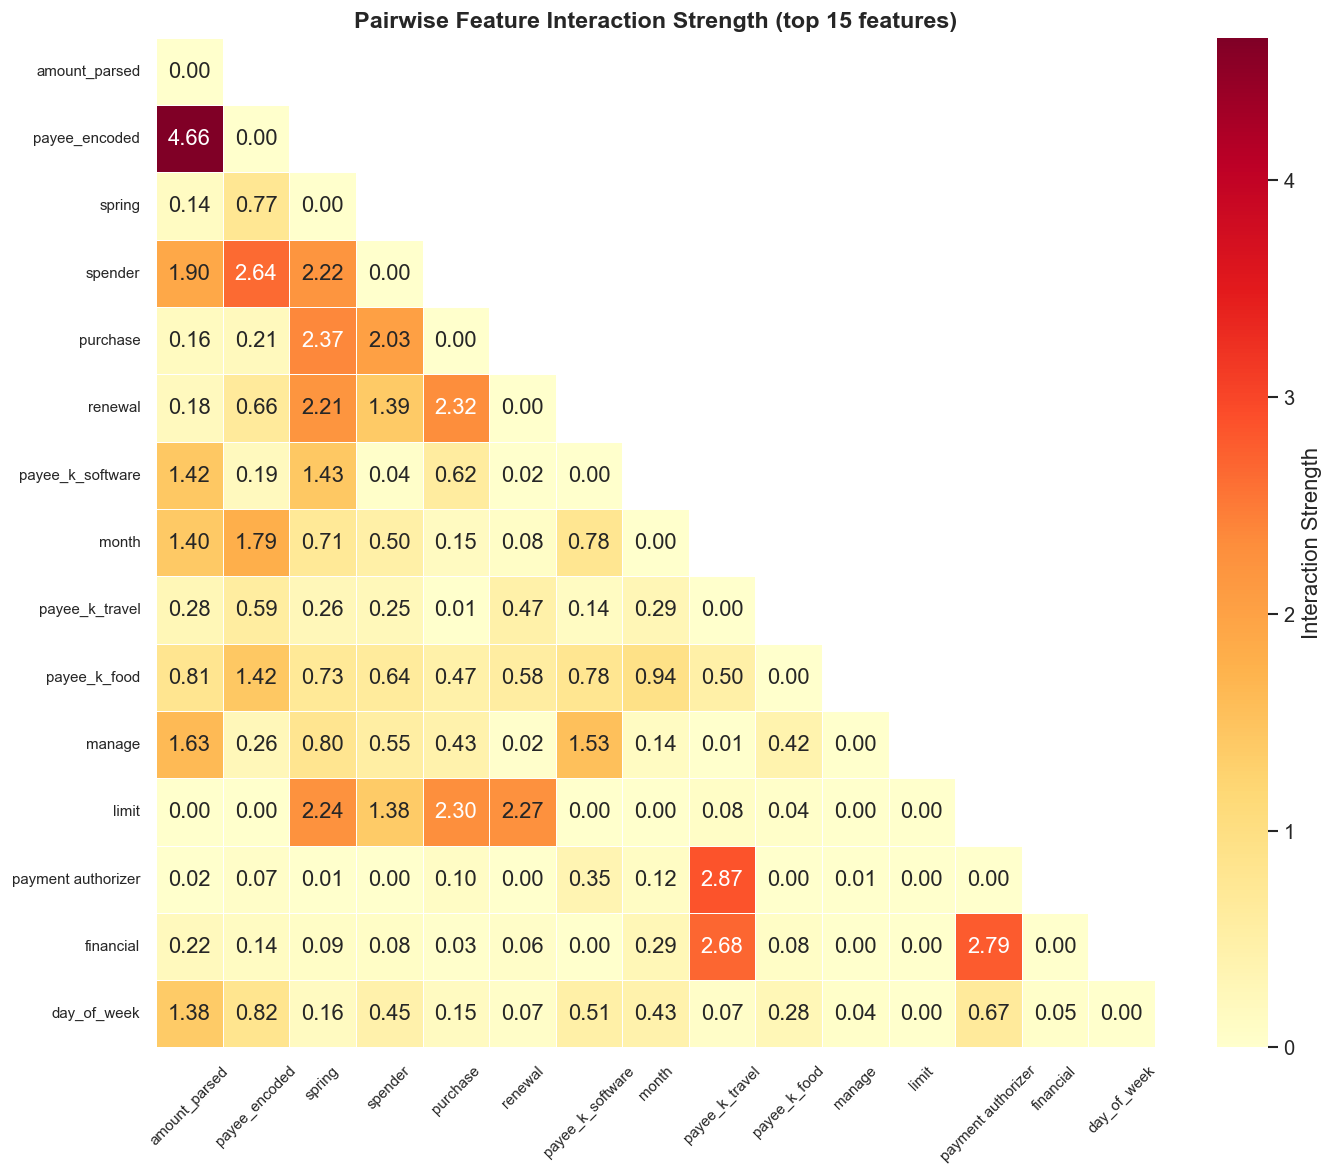

In [12]:
# ── Interaction heatmap (top 15 features by interaction participation) ──
# Sum interaction strength per feature
feat_int_sum = {}
for _, row in int_df.iterrows():
    feat_int_sum[row["feat_1"]] = feat_int_sum.get(row["feat_1"], 0) + row["strength"]
    feat_int_sum[row["feat_2"]] = feat_int_sum.get(row["feat_2"], 0) + row["strength"]

top_int_feats = sorted(feat_int_sum, key=feat_int_sum.get, reverse=True)[:15]

# Build symmetric matrix for top features
int_matrix = pd.DataFrame(0.0, index=top_int_feats, columns=top_int_feats)
for _, row in int_df.iterrows():
    if row["feat_1"] in top_int_feats and row["feat_2"] in top_int_feats:
        int_matrix.loc[row["feat_1"], row["feat_2"]] = row["strength"]
        int_matrix.loc[row["feat_2"], row["feat_1"]] = row["strength"]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(int_matrix, dtype=bool), k=1)
sns.heatmap(int_matrix, mask=mask, cmap="YlOrRd", annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Interaction Strength"})
ax.set_title("Pairwise Feature Interaction Strength (top 15 features)", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

## 7. Importance Comparison — All Three Methods Side-by-Side

Ranking features by three complementary importance measures to see which features are consistently important.

In [13]:
# Unified ranking table
comp = pd.DataFrame({"feature": FEATURE_NAMES})
comp["PredValChange"] = imp_pvc
comp["LossFuncChange"] = imp_lfc
comp["SHAP_global"] = [shap_df.loc[f, "GLOBAL"] if f in shap_df.index else 0 for f in FEATURE_NAMES]
comp["type"] = ["manual"] * len(manual_names) + ["tfidf"] * len(tfidf_names)

# Rank per method (1 = most important)
for col in ["PredValChange", "LossFuncChange", "SHAP_global"]:
    comp[f"{col}_rank"] = comp[col].rank(ascending=False).astype(int)

comp["avg_rank"] = comp[["PredValChange_rank", "LossFuncChange_rank", "SHAP_global_rank"]].mean(axis=1)
comp = comp.sort_values("avg_rank").reset_index(drop=True)

display(
    comp[["feature", "type", "PredValChange", "PredValChange_rank",
          "LossFuncChange", "LossFuncChange_rank",
          "SHAP_global", "SHAP_global_rank", "avg_rank"]]
    .style.hide(axis="index")
    .format({"PredValChange": "{:.2f}", "LossFuncChange": "{:.4f}",
             "SHAP_global": "{:.4f}", "avg_rank": "{:.1f}"})
    .background_gradient(subset=["avg_rank"], cmap="RdYlGn")
)

feature,type,PredValChange,PredValChange_rank,LossFuncChange,LossFuncChange_rank,SHAP_global,SHAP_global_rank,avg_rank
spender,manual,15.68,1,0.0859,2,0.6639,1,1.3
payee_encoded,manual,12.10,3,0.1112,1,0.4579,3,2.3
amount_parsed,manual,14.23,2,0.0659,5,0.6396,2,3.0
conversion rate_is_null,manual,11.61,4,0.0170,6,0.2362,6,5.3
month,manual,9.21,5,0.0162,8,0.3464,4,5.7
day_of_week,manual,5.71,6,0.0107,9,0.2606,5,6.7
payee_k_travel,manual,5.31,7,0.0671,4,0.1340,9,6.7
payee_k_software,manual,4.47,8,0.0162,7,0.2225,7,7.3
payee_k_food,manual,3.10,10,0.0764,3,0.1107,11,8.0
initial amount_is_null,manual,2.95,12,0.0059,10,0.1530,8,10.0


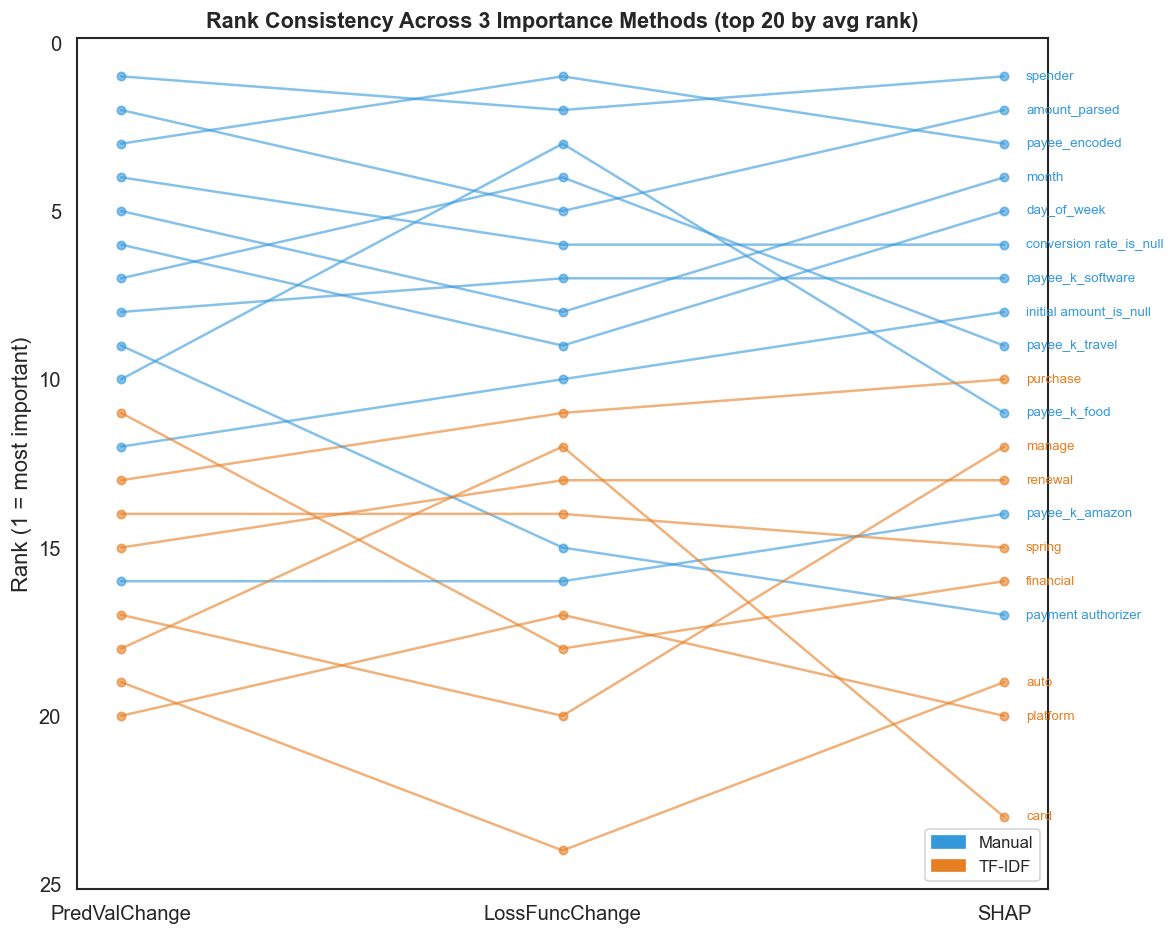

In [14]:
# ── Parallel rank plot ──
top_n = 20
plot_df = comp.head(top_n).copy()

fig, ax = plt.subplots(figsize=(10, 8))
for _, row in plot_df.iterrows():
    ranks = [row["PredValChange_rank"], row["LossFuncChange_rank"], row["SHAP_global_rank"]]
    color = "#3498db" if row["type"] == "manual" else "#e67e22"
    ax.plot([0, 1, 2], ranks, "-o", color=color, alpha=0.6, linewidth=1.5, markersize=5)
    ax.text(2.05, ranks[-1], row["feature"], fontsize=8, va="center", color=color)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["PredValChange", "LossFuncChange", "SHAP"])
ax.set_ylabel("Rank (1 = most important)")
ax.set_title(f"Rank Consistency Across 3 Importance Methods (top {top_n} by avg rank)",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.legend(handles=[Patch(color="#3498db", label="Manual"),
                   Patch(color="#e67e22", label="TF-IDF")],
          loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

## 8. Manual vs TF-IDF Importance Split

Aggregate importance by feature type to quantify how much predictive signal comes from manually-engineered features vs text-derived TF-IDF features.

Aggregated importance by feature type:



PredValChange                 LossFuncChange                  \
                 sum      mean count            sum      mean count   
type                                                                  
manual     89.465191  3.889791    23       0.476159  0.020703    23   
tfidf      10.534809  0.390178    27       0.013984  0.000518    27   

       SHAP_global                  
               sum      mean count  
type                                
manual    3.328740  0.144728    23  
tfidf     0.552614  0.020467    27

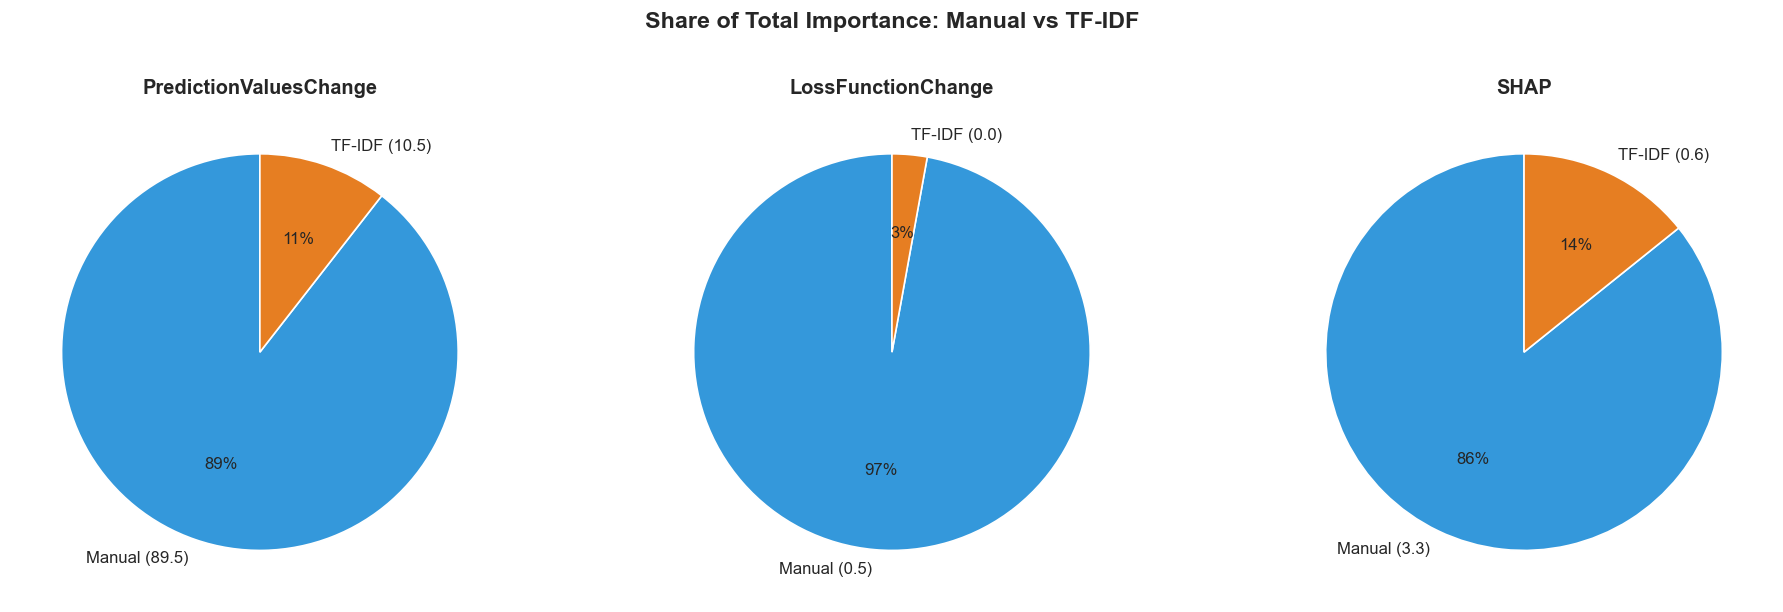

In [15]:
group_df = comp.groupby("type")[["PredValChange", "LossFuncChange", "SHAP_global"]].agg(["sum", "mean", "count"])
print("Aggregated importance by feature type:\n")
display(group_df)

# Pie charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes,
                           ["PredValChange", "LossFuncChange", "SHAP_global"],
                           ["PredictionValuesChange", "LossFunctionChange", "SHAP"]):
    sums = comp.groupby("type")[col].sum()
    ax.pie(sums, labels=[f"Manual ({sums['manual']:.1f})", f"TF-IDF ({sums['tfidf']:.1f})"],
           colors=["#3498db", "#e67e22"], autopct="%1.0f%%", startangle=90,
           textprops={"fontsize": 10})
    ax.set_title(title, fontsize=12, fontweight="bold")
plt.suptitle("Share of Total Importance: Manual vs TF-IDF", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 9. Tree Split Statistics

How often each feature is used as a split variable across all 500 trees, and at which depth levels.

In [17]:
# Extract tree structure via JSON export
import json, tempfile, os

tmpf = tempfile.NamedTemporaryFile(suffix=".json", delete=False)
tmpf.close()
clf.save_model(tmpf.name, format="json")
with open(tmpf.name) as f:
    model_json = json.load(f)
os.unlink(tmpf.name)

trees = model_json["oblivious_trees"]
depth = len(trees[0]["splits"])  # oblivious tree depth

# Count splits per feature index and per depth level
from collections import Counter
feat_split_count = Counter()
feat_depth_counts = {}  # {feat_idx: Counter(depth_level -> count)}

for tree in trees:
    for level, split in enumerate(tree["splits"]):
        fidx = split["float_feature_index"]
        feat_split_count[fidx] += 1
        feat_depth_counts.setdefault(fidx, Counter())[level] += 1

# Map to feature names
split_df = pd.DataFrame([
    {"feature": FEATURE_NAMES[idx], "split_count": count,
     "type": "manual" if FEATURE_NAMES[idx] in manual_names else "tfidf"}
    for idx, count in feat_split_count.most_common()
])
split_df["pct_of_trees"] = (split_df["split_count"] / clf.tree_count_ * 100).round(1)

used = set(split_df["feature"])
n_unused = len(FEATURE_NAMES) - len(split_df)
print(f"Features used in splits: {len(split_df)} / {len(FEATURE_NAMES)}")
if n_unused > 0:
    unused = [f for f in FEATURE_NAMES if f not in used]
    print(f"Never used in a split ({n_unused}): {unused}")

print()
display(split_df.style.hide(axis="index").background_gradient(
    subset=["split_count"], cmap="YlOrRd"
))

Features used in splits: 33 / 50
Never used in a split (17): ['approver', 'account_is_null', 'initial currency_is_null', 'last 4 digits_is_null', 'invoice number_is_null', 'fx initial currency_is_null', 'fx initial amount_is_null', 'detail_is_null', 'transaction type_purchase', 'cypress hill use', 'cypress portfolio', 'cypress portfolio 20', 'match renewal', 'product', 'product manage', 'update', 'update card limit']



feature,split_count,type,pct_of_trees
payee_encoded,698,manual,139.600000
amount_parsed,577,manual,115.400000
spender,259,manual,51.800000
month,213,manual,42.600000
day_of_week,154,manual,30.800000
payee_k_food,108,manual,21.600000
platform,70,tfidf,14.000000
need,64,tfidf,12.800000
initial amount_is_null,51,manual,10.200000
manage,42,tfidf,8.400000


## 10. Cumulative Importance — How Many Features Are Needed?

Shows what percentage of total PredictionValuesChange importance is covered as we add features from most to least important. Helps decide if we can safely drop the tail.

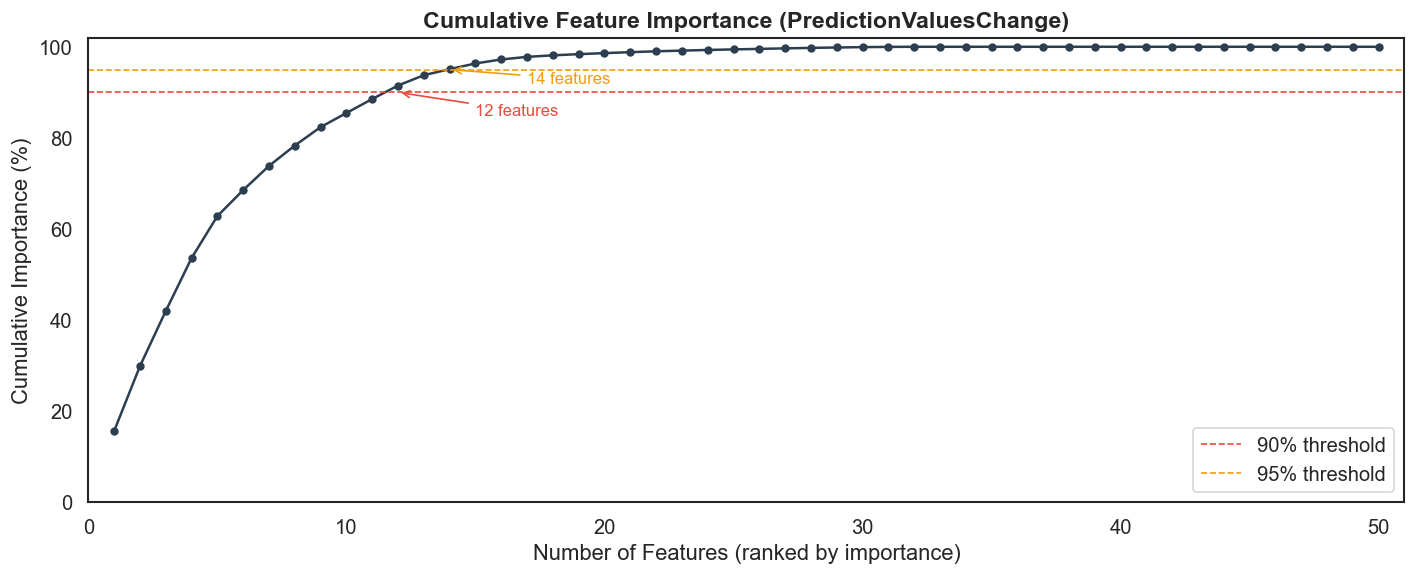

Features needed for 90% importance: 12 / 50
Features needed for 95% importance: 14 / 50

Features beyond 95%: ['renewal', 'payee_k_amazon', 'manage', 'card', 'auto', 'platform', 'match renewal requirement', 'use passtime platform', 'cypress hill', 'update card', 'transaction type_bill payment', 'passtime', 'need', 'product manage cypress', 'use', 'use passtime', 'transaction type_refund', 'limit', 'cypress', 'last 4 digits_is_null', 'detail_is_null', 'transaction type_purchase', 'invoice number_is_null', 'product', 'product manage', 'fx initial amount_is_null', 'fx initial currency_is_null', 'cypress portfolio', 'account_is_null', 'update', 'update card limit', 'cypress hill use', 'approver', 'initial currency_is_null', 'match renewal', 'cypress portfolio 20']


In [18]:
sorted_imp = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)
sorted_imp["cum_pct"] = sorted_imp["importance"].cumsum() / sorted_imp["importance"].sum() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(sorted_imp) + 1), sorted_imp["cum_pct"], "-o", color="#2c3e50", markersize=4)
ax.axhline(90, color="#e74c3c", linestyle="--", linewidth=1, label="90% threshold")
ax.axhline(95, color="#f39c12", linestyle="--", linewidth=1, label="95% threshold")

# Annotate the feature counts at 90% and 95%
n_90 = (sorted_imp["cum_pct"] >= 90).idxmax() + 1
n_95 = (sorted_imp["cum_pct"] >= 95).idxmax() + 1
ax.annotate(f"{n_90} features", xy=(n_90, 90), fontsize=10, color="#e74c3c",
            xytext=(n_90 + 3, 85), arrowprops=dict(arrowstyle="->", color="#e74c3c"))
ax.annotate(f"{n_95} features", xy=(n_95, 95), fontsize=10, color="#f39c12",
            xytext=(n_95 + 3, 92), arrowprops=dict(arrowstyle="->", color="#f39c12"))

ax.set_xlabel("Number of Features (ranked by importance)")
ax.set_ylabel("Cumulative Importance (%)")
ax.set_title("Cumulative Feature Importance (PredictionValuesChange)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.set_xlim(0, len(sorted_imp) + 1)
ax.set_ylim(0, 102)
plt.tight_layout()
plt.show()

print(f"Features needed for 90% importance: {n_90} / {len(FEATURE_NAMES)}")
print(f"Features needed for 95% importance: {n_95} / {len(FEATURE_NAMES)}")
print(f"\nFeatures beyond 95%: {sorted_imp.iloc[n_95:]['feature'].tolist()}")